In [13]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib_venn import venn3
import os 
import itertools

In [7]:
#Loading the model and Task 1 data 
model = joblib.load("baseline_rf.joblib")

f5_train = pd.read_csv("f5_train.csv")
f5_test  = pd.read_csv("f5_test.csv")

## Finding optimum threshold based on pr-auc (using f1)

In [3]:
feature_cols = [c for c in f5_train.columns if c not in ["transcript_id", "transcript_position", "label"]]
X_test = f5_test[feature_cols]
y_test = f5_test["label"].astype(int)

# Predict probabilities on test split 
y_prob = model.predict_proba(X_test)[:, 1]

# Best F1 threshold 
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Threshold selection based on Task 1")
print(f"PR-AUC:            {pr_auc:.4f}")
print(f"Best F1:           {f1_scores[best_idx]:.4f}")
print(f"Optimal threshold: {best_threshold:.6f}")

Threshold selection based on Task 1
PR-AUC:            0.3501
Best F1:           0.4234
Optimal threshold: 0.220000


## Cleaning the prediction files - for transcript ids with versions 

In [4]:
# List of all standardized prediction files 
files = [
    "A549_predictions.csv",
    "Hct116_predictions.csv",
    "HepG2_predictions.csv",
    "K562_predictions.csv",
    "MCF7_predictions.csv"
]

# Clean and overwrite each file 
for file in files:
    if os.path.exists(file):
        print(f"Cleaning {file} ...")

        # Load CSV
        df = pd.read_csv(file)

        # Remove version number from transcript_id (e.g. .1, .2, etc.)
        if "transcript_id" in df.columns:
            df["transcript_id"] = df["transcript_id"].astype(str).str.replace(r"\.\d+$", "", regex=True)
        else:
            print(f"⚠️ No 'transcript_id' column found in {file}, skipping.")
            continue

        # Save cleaned file (overwrite)
        df.to_csv(file, index=False)
        print(f"Cleaned and saved: {file}\n")
    else:
        print(f"⚠️ File not found: {file}\n")

print(" All transcript IDs cleaned successfully across prediction files.")

Cleaning A549_predictions.csv ...
Cleaned and saved: A549_predictions.csv

Cleaning Hct116_predictions.csv ...
Cleaned and saved: Hct116_predictions.csv

Cleaning HepG2_predictions.csv ...
Cleaned and saved: HepG2_predictions.csv

Cleaning K562_predictions.csv ...
Cleaned and saved: K562_predictions.csv

Cleaning MCF7_predictions.csv ...
Cleaned and saved: MCF7_predictions.csv

 All transcript IDs cleaned successfully across prediction files.


## Feature Importance plot 

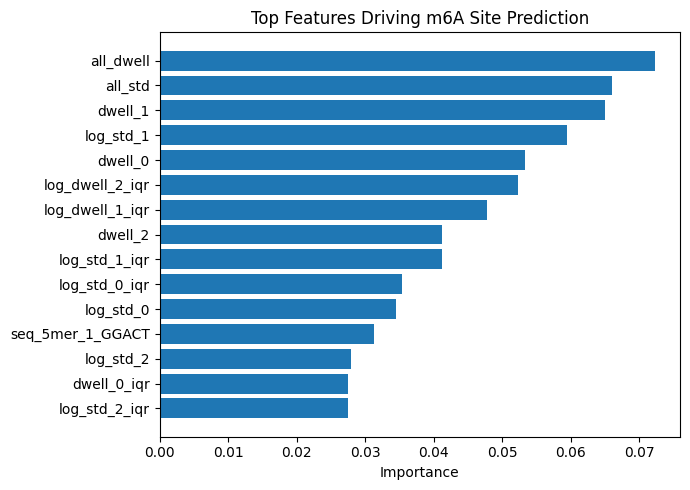

In [9]:
# Define feature cols 
feature_cols = [c for c in f5_train.columns if c not in ["transcript_id", "transcript_position", "label"]]

# Compute feature importances
model = joblib.load("baseline_rf.joblib")
importances = model.feature_importances_
feat_names = feature_cols  
top_idx = np.argsort(importances)[-15:][::-1]

plt.figure(figsize=(7,5))
plt.barh(range(len(top_idx)), importances[top_idx][::-1])
plt.yticks(range(len(top_idx)), [feat_names[i] for i in top_idx][::-1])
plt.xlabel("Importance")
plt.title("Top Features Driving m6A Site Prediction")
plt.tight_layout()
plt.show()



From the feature importance plot, it’s clear that the model relies heavily on signal-based features like all_dwell, all_std, and log_std_1. These represent how much the nanopore current and dwell time fluctuate near potential m⁶A sites. In contrast, sequence-based features such as the 5-mer motif GGACT contribute less. This suggests that the model is picking up on differences in the electrical signal caused by methylation rather than depending mainly on sequence context, which makes sense since m⁶A modifications often affect the local signal pattern more than the nucleotide sequence itself.

## Correlation plot on the top 5 features 

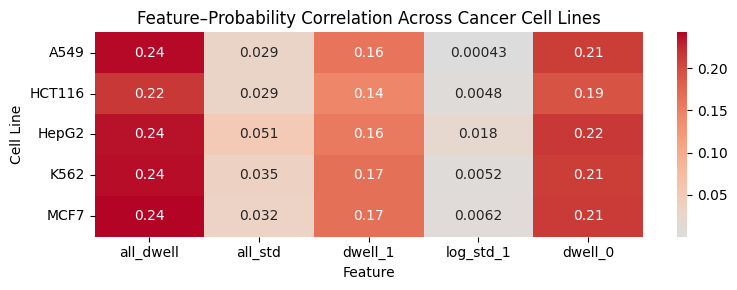

In [12]:
#Standardized file names 
cell_lines = {
    "A549":   ("A549_predictions.csv", "preprocessed_a549.csv"),
    "HCT116": ("Hct116_predictions.csv", "preprocessed_hct.csv"),
    "HepG2":  ("HepG2_predictions.csv", "preprocessed_hep2.csv"),
    "K562":   ("K562_predictions.csv", "preprocessed_k562.csv"),
    "MCF7":   ("MCF7_predictions.csv", "preprocessed_mc67.csv")
}

# Top 5 most important features 
top5_features = ["all_dwell", "all_std", "dwell_1", "log_std_1", "dwell_0"]

# Store correlations for all cell lines
corrs_all = {}

for name, (pred_file, feat_file) in cell_lines.items():
    try:
        preds = pd.read_csv(pred_file)
        features = pd.read_csv(feat_file)

        # Ensure no decimals in transcript_id before merging
        preds["transcript_id"] = preds["transcript_id"].astype(str).str.replace(r"\.\d+$", "", regex=True)
        features["transcript_id"] = features["transcript_id"].astype(str).str.replace(r"\.\d+$", "", regex=True)

        # Merge on transcript and position
        df = pd.merge(preds, features, on=["transcript_id", "transcript_position"], how="inner")

        # Compute correlations
        corrs = df[top5_features + ["score"]].corr()["score"].drop("score")
        corrs_all[name] = corrs


    except Exception as e:
        print(f"⚠️ Skipped {name}: {e}")

# Convert to DataFrame for heatmap 
corr_df = pd.DataFrame(corrs_all).T

# Plot 
plt.figure(figsize=(8, 3))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0)
plt.title("Feature–Probability Correlation Across Cancer Cell Lines")
plt.xlabel("Feature")
plt.ylabel("Cell Line")
plt.tight_layout()
plt.show()


The correlation plot shows that features related to dwell time (all_dwell, dwell_1, and dwell_0) are consistently the strongest indicators of m⁶A methylation probability across all five cancer cell lines. Sites with longer dwell times generally receive higher predicted m6A scores, suggesting a clear link between slowed RNA translocation through the nanopore and the presence of m⁶A modifications. 

In contrast, features capturing signal variability (all_std, log_std_1) show weaker correlations, meaning they contribute less directly to predicting modification probability. The consistent correlation patterns across A549, HCT116, HEPG2, K562, and MCF7 imply that the model relies on a common physical signal signature of m6A, even though each cell line has a distinct set of modified sites.

## Metagene plot 

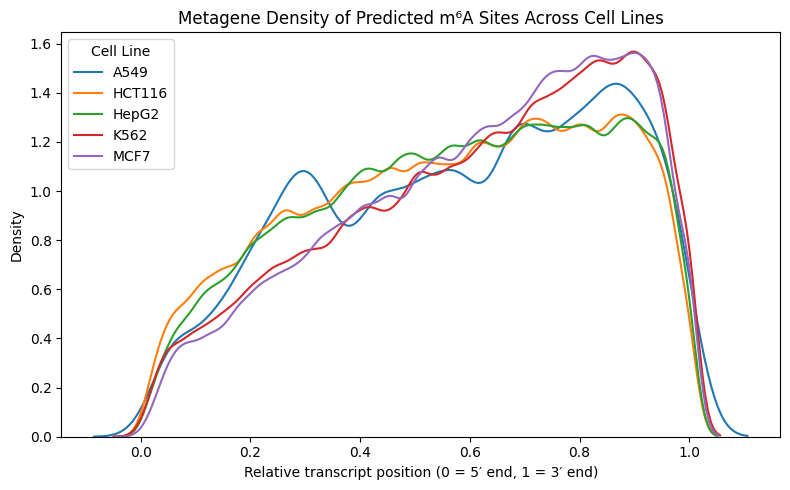

In [17]:
cell_lines = {
    "A549": "A549_predictions.csv",
    "HCT116": "Hct116_predictions.csv",
    "HepG2": "HepG2_predictions.csv",
    "K562": "K562_predictions.csv",
    "MCF7": "MCF7_predictions.csv"
}

#  Load all predictions into a dictionary 
results = {cell: pd.read_csv(file) for cell, file in cell_lines.items()}

#  Helper function to compute relative transcript position
def compute_relative(df):
    if 'transcript_length' in df.columns:
        df['relative_pos'] = df['transcript_position'] / df['transcript_length']
    else:
        # Approximate relative position using rank of site within transcript
        df['pos_rank'] = df.groupby('transcript_id')['transcript_position'].rank(method='max')
        df['max_rank'] = df.groupby('transcript_id')['pos_rank'].transform('max')
        df['relative_pos'] = df['pos_rank'] / df['max_rank']
    return df

# Plot kernel density of predicted modified sites 
plt.figure(figsize=(8,5))

threshold = 0.22  

for cell, df in results.items():
    df = compute_relative(df)
    if "score" not in df.columns:
        raise ValueError(f"'score' column missing in {cell} dataset.")
    # Predicted modified sites
    modified = df.loc[df['score'] >= threshold, 'relative_pos']
    if len(modified) == 0:
        print(f"{cell}: no sites above threshold.")
        continue
    sns.kdeplot(modified, label=cell, bw_adjust=0.5)

plt.xlabel("Relative transcript position (0 = 5′ end, 1 = 3′ end)")
plt.ylabel("Density")
plt.title("Metagene Density of Predicted m⁶A Sites Across Cell Lines")
plt.legend(title="Cell Line")
plt.tight_layout()
plt.show()

The metagene plot shows where the predicted m6A sites are located along transcripts. Most modifications were concentrated near the stop codon and 3′ UTR region, matching known m6A patterns from previous studies. This suggests that the model correctly captured the typical m6A distribution. While all cell lines showed similar trends, MCF7 and K562 had stronger peaks at the 3′ UTR, and A549 showed a slightly wider spread into the coding region. These differences may reflect how m6A regulation varies across cell types.



## Pairwise overlap plot 

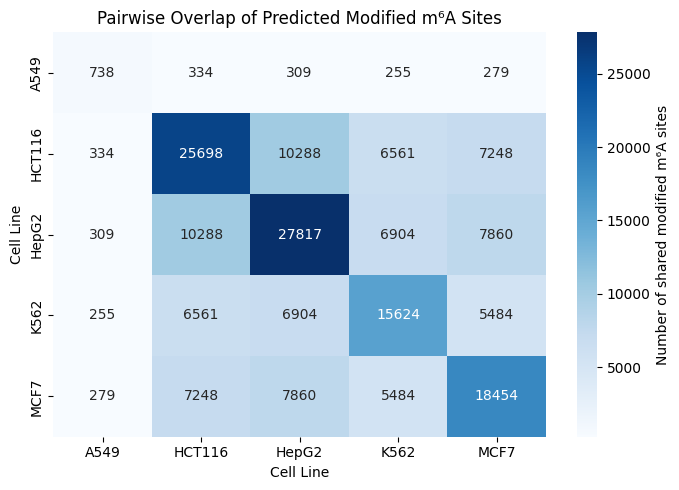

In [15]:
# Define your prediction files 
cell_lines = {
    "A549": "A549_predictions.csv",
    "HCT116": "Hct116_predictions.csv",
    "HepG2": "HepG2_predictions.csv",
    "K562": "K562_predictions.csv",
    "MCF7": "MCF7_predictions.csv"
}

# Load datasets into a dict of DataFrames 
results = {cell: pd.read_csv(file) for cell, file in cell_lines.items()}

# Define helper to extract predicted sites 
def site_set(df, threshold=0.220):
    if "score" not in df.columns:
        raise ValueError("Expected a 'score' column in prediction file.")
    df["site"] = df["transcript_id"].astype(str) + ":" + df["transcript_position"].astype(str)
    return set(df.loc[df["score"] >= threshold, "site"])

# Build sets of predicted modified sites 
sets = {cell: site_set(df) for cell, df in results.items()}

# Create pairwise overlap matrix 
cells = list(sets.keys())
overlap = pd.DataFrame(index=cells, columns=cells, data=0)

for i in cells:
    for j in cells:
        overlap.loc[i, j] = len(sets[i] & sets[j])

# Plot heatmap 
plt.figure(figsize=(7, 5))
sns.heatmap(
    overlap.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Number of shared modified m⁶A sites"}
)
plt.title("Pairwise Overlap of Predicted Modified m⁶A Sites")
plt.xlabel("Cell Line")
plt.ylabel("Cell Line")
plt.tight_layout()
plt.show()
